In [1]:
from scipy.io import loadmat
import numpy as np

import requests
import tarfile

from pathlib import Path
import re
import shutil
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.io import decode_image
from torch.utils.data import Dataset
from torchinfo import summary
import os
from matplotlib import pyplot as plt

import math
from dataclasses import dataclass

import torch.nn.functional as F



device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# define directory names
root_dir = './data'
src_dir = './data/jpg' # this is just where i have all the pics
train_dir = './data/train'
val_dir = './data/val'
test_dir = './data/test'


## Data splits

In [2]:
def download_file(url, download_path):
    # Download the file with streaming to handle large files efficiently
    print(f"Downloading from: {url}")
    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status() # Raise an exception for bad status codes
            with open(download_path, 'wb') as f:
                shutil.copyfileobj(r.raw, f)
        print(f"Download complete: {download_path}")
    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

def download_and_extract_tgz(url, download_path, extract_path):
    # 1. Ensure the extract directory exists
    os.makedirs(extract_path, exist_ok=True)
    print(f"Ensured extraction directory exists: {extract_path}")

    # 2. Download the file with streaming to handle large files efficiently
    print(f"Downloading from: {url}")
    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status() # Raise an exception for bad status codes
            with open(download_path, 'wb') as f:
                shutil.copyfileobj(r.raw, f)
        print(f"Download complete: {download_path}")

        # 3. Extract the .tgz file
        print(f"Extracting to: {extract_path}")
        with tarfile.open(download_path, 'r:gz') as tar_file:
            tar_file.extractall(path=extract_path)
        print("Extraction complete.")

    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")
    except tarfile.TarError as e:
        print(f"Extraction failed: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        # Optional: Remove the downloaded .tgz file after extraction
        if os.path.exists(download_path):
            os.remove(download_path)
            print(f"Removed temporary download file: {download_path}")

In [3]:
# download dataset:
dataset_url = 'https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz'
temp_file_name = 'images.tgz'
destination_folder = './data'
download_and_extract_tgz(dataset_url, temp_file_name, destination_folder)

# download metadata files
metadata_files = [('https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat','./data/imagelabels.mat'),
                  ('https://www.robots.ox.ac.uk/~vgg/data/flowers/102/setid.mat', './data/setid.mat')
                  ]

for url, file in metadata_files:
    download_file(url, file)

Ensured extraction directory exists: ./data
Download complete: images.tgz
Extracting to: ./data
Extraction complete.
Removed temporary download file: images.tgz
Download complete: ./data/imagelabels.mat
Download complete: ./data/setid.mat


In [10]:
def ensure_split_folder(split_dir, split_ids, labels, source_dir="./data/jpg"):
    source_path = Path(source_dir)
    target_path = Path(split_dir)

    if target_path.exists():
        print(f"{target_path} already exists; skipping creation.")
        return target_path

    target_path.mkdir(parents=True, exist_ok=True)
    split_id_set = set(np.asarray(split_ids).reshape(-1).astype(int).tolist())
    labels_arr = np.asarray(labels).reshape(-1).astype(int)

    copied = 0
    for file_path in tqdm(source_path.iterdir()):
        if not file_path.is_file():
            continue

        match = re.search(r"(\d+)(?!.*\d)", file_path.stem)
        if not match:
            continue

        sample_id = int(match.group(1))
        if sample_id not in split_id_set:
            continue

        label = int(labels_arr[sample_id - 1])
        label_dir = target_path / str(label)
        label_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy2(file_path, label_dir / file_path.name)
        copied += 1

    print(f"Created {target_path} with {copied} files.")
    return target_path


In [11]:
# define directory names
root_dir = './data'
src_dir = './data/jpg' # this is just where i have all the pics
train_dir = './data/train'
val_dir = './data/val'
test_dir = './data/test'

# load in set splits
# it looks like the train and test set ids are swapped for some reason? 
# test has 6000 examples, and train only has 1000 (same as val)
# swap these here so that we actually train on training data
setid = loadmat("./data/setid.mat")
labels = loadmat("./data/imagelabels.mat")['labels']
test = setid['trnid']
val = setid['valid']
train = setid['tstid']

# split data into train, val, test
# we just copyin for now since the dataset is so small
ensure_split_folder(train_dir, train, labels)
ensure_split_folder(val_dir, val, labels)
ensure_split_folder(test_dir, test, labels)


data/train already exists; skipping creation.
data/val already exists; skipping creation.
data/test already exists; skipping creation.


PosixPath('data/test')

In [12]:
print(setid['trnid'].shape)
print(setid['tstid'].shape)
print(setid['valid'].shape)

(1, 1020)
(1, 6149)
(1, 1020)


## DataLoader definitions

In [17]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

In [6]:
# dataset is small and can be loaded onto gpu, so do that to speed up training
def make_gpu_dataset(directory: Path, transform, two_view: bool = True):
    dataset = ImageFolder(
        root=directory,
        transform=transform
        )
    
    all_images = []
    all_labels = []

    # Iterate through the dataset and collect all items (this may take time)
    for i in tqdm(range(len(dataset))):
        if two_view:
            (view1, view2), label = dataset[i]
            views = torch.stack((view1, view2))
        else:
            views, label = dataset[i]
        all_images.append(views)
        all_labels.append(label)
    # Stack the list of tensors into single large tensors
    # Use torch.stack to combine the list of individual image tensors
    images_tensor = torch.stack(all_images)
    labels_tensor = torch.tensor(all_labels)

    # Move the entire tensors to the specified device (GPU)
    images_gpu = images_tensor.to(device)
    labels_gpu = labels_tensor.to(device)

    print(f"Dataset loaded to GPU. Images shape: {images_gpu.shape}, Labels shape: {labels_gpu.shape}")

    # Wrap the GPU tensors in a TensorDataset
    gpu_dataset = TensorDataset(images_gpu, labels_gpu)

    # Create a DataLoader for batching (batch size can be large, limited by VRAM)
    return gpu_dataset

In [7]:
# two views for contrastive objective
class TwoViewTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, x):
        view1 = self.base_transform(x)
        view2 = self.base_transform(x)
        return view1, view2
    
simclr_train_val_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomApply(
        [T.ColorJitter(0.4, 0.4, 0.4, 0.1)],
        p=0.8
    ),
    #T.RandomGrayscale(p=0.2), # OG SimCLR doesnt use this
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(mean, std)
])
simclr_test_transform = T.Compose([T.RandomResizedCrop(224, scale=(0.6, 1.0)),
                                   T.ToTensor(),
                                   T.Normalize(mean, std)])

### ATTENTION ###
### if you don't want the added speed or need the GPU memory, set this to false
load_data_directly_onto_gpu = False
if load_data_directly_onto_gpu:    
    train_set = make_gpu_dataset(train_dir, TwoViewTransform(simclr_train_val_transform))
else:
    train_set = ImageFolder(
        root=train_dir,
        transform=TwoViewTransform(simclr_train_val_transform)
        )    


In [8]:
train_loader = DataLoader(train_set, 
                          batch_size=512, 
                          shuffle=True, 
                          num_workers=8, 
                          drop_last=True)


# MAE Load

In [18]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

def get_mae_dataloader(data_dir, batch_size=256, num_workers=8):
    dataset = ImageFolder(
        root=data_dir,
        transform=mae_transform
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    
    return loader
    
mae_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.2, 1.0), interpolation=3),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std)
])

train_loader = get_mae_dataloader(train_dir)

## SimCLR Model

In [30]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = out + x
        return self.relu(out)


class ResNet9Encoder(nn.Module):
    def __init__(self, in_channels=3, feat_dim=512):
        super().__init__()
        self.feat_dim = feat_dim
        self.stem = nn.Sequential(
            ConvBNReLU(in_channels, 32, 7, 2, 3),
            ConvBNReLU(32, 64, 3, 2, 1),
            nn.MaxPool2d(2),
        )
        self.res1 = ResidualBlock(64)

        self.mid = nn.Sequential(
            ConvBNReLU(64, 128, 3, 1, 1),
            nn.MaxPool2d(2),
            ConvBNReLU(128, 256, 3, 1, 1),
            nn.MaxPool2d(2),
        )
        self.res2 = ResidualBlock(256)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, feat_dim)

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(x)
        x = self.mid(x)
        x = self.res2(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class ResNet18Encoder(nn.Module):
    def __init__(self, freeze: bool = True, retrain_layer4: bool = True):
        super().__init__()

        if freeze:
            weights = ResNet18_Weights.DEFAULT
            self.resnet18 = resnet18(weights=weights)
        else:
            self.resnet18 = resnet18(weights=None)

        # replace last layer with linear projection head
        self.resnet18.fc = nn.Identity()

        if freeze:
            for param in self.resnet18.parameters():
                param.requires_grad = False
        
        if freeze and retrain_layer4:
            # Unfreeze the parameters in the last block (layer4)
            for param in self.resnet18.layer4.parameters():
                param.requires_grad = True

        # Unfreeze the parameters in the new fully connected layer (fc)
        for param in self.resnet18.fc.parameters():
            param.requires_grad = True
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.resnet18(x)

class SimCLR(nn.Module):
    def __init__(self, encoder: nn.Module, 
                 encoder_out_features: int, 
                 out_features=128):
        super().__init__()
        
        self.encoder = encoder

        # projection head
        self.projector = nn.Sequential(
            nn.Linear(encoder_out_features, 256),
            nn.ReLU(),
            nn.Linear(256, out_features)
        )      

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y_pred = self.encoder(x)
        y_pred = self.projector(y_pred)
        return y_pred
    
    @torch.no_grad()
    def representation(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

## NT-XENT loss function

In [31]:
import torch
import torch.nn.functional as F

def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.2) -> torch.Tensor:
    if z1.ndim != 2 or z2.ndim != 2:
        raise ValueError(f"z1 and z2 must be 2D (B,D). Got {z1.shape} and {z2.shape}.")
    if z1.shape != z2.shape:
        raise ValueError(f"z1 and z2 must have the same shape. Got {z1.shape} vs {z2.shape}.")

    B, D = z1.shape
    if B < 2:
        raise ValueError("Batch size must be >= 2 for contrastive loss (needs negatives).")

    # concatenate for a (2B, D) tensor
    z = torch.cat([z1, z2], dim=0)  # (2B, D)

    # cosine similarity
    sim = F.cosine_similarity(z[None,:,:], z[:,None,:], dim=-1)
    
    # mask self similarity
    sim[torch.eye(z.size(0)).bool()] = float("-inf")

    # positive indices:
    # For i in [0..B-1] (z1), positive is i+B (z2)
    # For i in [B..2B-1] (z2), positive is i-B (z1)
    pos_idx = torch.arange(2 * B, device=z.device)
    pos_idx = (pos_idx + B) % (2 * B)

    # cross-entropy loss where each anchor predicts its positive among 2B-1 candidates
    # Targets: for each row i, the positive is at column pos_idx[i]
    loss = F.cross_entropy(sim/temperature, pos_idx)

    return loss

## Train SimCLR

In [32]:
def train_simCLR_model(model: nn.Module, 
                       train_loader: DataLoader, 
                       epochs: int, 
                       lr: float):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    results = {"train_loss": [], "val_loss": []}
    for ep in range(1, epochs + 1):
        running = 0.0
        n_batches = 0
        pbar = tqdm(train_loader, desc=f"epoch {ep}/{epochs}", leave=False)
        
        model.train()
        for sample in pbar:
            views, _ = sample
            if load_data_directly_onto_gpu:
                x1 = views[:,0,:,:,:] #list obj
                x2 = views[:,1,:,:,:]
            else:
                x1 = views[0].to(device)
                x2 = views[1].to(device)
            z1 = model(x1)
            z2 = model(x2)
        
            loss = nt_xent_loss(z1, z2)
            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.item())
            n_batches += 1
            pbar.set_postfix(loss=running / n_batches)
        
        train_loss = running / max(1, n_batches)
        results["train_loss"].append(train_loss)
    
        if ep % 10 == 0:
            print(f"epoch {ep}: train_loss={train_loss:.4f}")
    results['model'] = model
    return results

In [ ]:
encoder = ResNet9Encoder()
simCLR = SimCLR(encoder, 512)

lr = 1e-3
epochs = 100
results = train_simCLR_model(simCLR, train_loader, epochs, lr)


epoch 10: train_loss=3.4876


epoch 20: train_loss=3.0922


epoch 30: train_loss=2.9593


epoch 40: train_loss=2.8704


epoch 50: train_loss=2.7861


epoch 60: train_loss=2.7316


epoch 70: train_loss=2.6784


epoch 80: train_loss=2.6641


epoch 90: train_loss=2.6228


epoch 92/100:   0%|                                      | 0/12 [00:00<?, ?it/s]

In [ ]:
from matplotlib import pyplot as plt
plt.title("loss curve")
plt.plot(results['train_loss'])

# MAE

In [38]:
# ------------------------------------------------------------
# Config
# ------------------------------------------------------------

@dataclass
class MAEConfig:
    img_size: int = 224
    patch_size: int = 16
    in_chans: int = 3

    enc_embed_dim: int = 384*2
    enc_depth: int = 16
    enc_num_heads: int = 12
    mlp_ratio: float = 4.0

    dec_embed_dim: int = 512
    dec_depth: int = 4
    dec_num_heads: int = 16

    mask_ratio: float = 0.80
    norm_pix_loss: bool = True


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def denormalize(tensor):
    """
    Args: tensor [3, H, W]
    Returns: numpy array [H, W, 3] ready for plt.imshow
    """
    # Clone to avoid modifying the original tensor
    t = tensor.clone().cpu()
    
    # Reverse the normalization
    for i in range(3):
        t[i] = t[i] * std[i] + mean[i]
        
    # Clamp to [0, 1] range to avoid floating point errors
    t = torch.clamp(t, 0, 1)
    
    # [3, H, W] -> [H, W, 3]
    return t.permute(1, 2, 0).numpy()

@torch.no_grad()
def get_mae_features(mae_model, imgs):
    """
    Extracts the global CLS token features from the pre-trained MAE.
    imgs: [B, 3, 224, 224]
    returns: [B, enc_embed_dim]
    """
    # 1. Image -> Patches [B, L, D]
    x = mae_model.patch_embed(imgs)

    # 2. Add positional embeddings (Skip index 0, which is for CLS)
    x = x + mae_model.pos_embed_enc[:, 1:, :]

    # 3. Prepare and prepend CLS token
    # We add the 0th pos_embed so the transformer knows this is the "summary" slot
    cls_token = mae_model.cls_token + mae_model.pos_embed_enc[:, :1, :]
    cls_tokens = cls_token.expand(x.shape[0], -1, -1)
    x = torch.cat([cls_tokens, x], dim=1)

    # 4. Pass through the Transformer Blocks (Full Attention, No Masking)
    for blk in mae_model.encoder_blocks:
        x = blk(x)
    x = mae_model.enc_norm(x)

    # 5. Extract only the CLS token (the global representation)
    return x[:, 0, :]
    #return x[:, 1:, :].mean(dim=1)
def get_2d_sincos_pos_embed(embed_dim: int, grid_size: int, cls_token: bool = False):
    """
    Stub for fixed 2D sin-cos positional embeddings.

    DONE:
      - Implement 2D sin/cos embedding generation
      - Return shape:
            [1 + grid_size*grid_size, embed_dim] if cls_token
            [grid_size*grid_size, embed_dim] otherwise
    """
    half_dim = embed_dim//2
    
    x_coord = np.arange(grid_size, dtype=np.float32) 
    y_coord = np.arange(grid_size, dtype=np.float32) 

    grid_x, grid_y = np.meshgrid(x_coord, y_coord)

    pos_x = grid_x.flatten() #[0, 1, 2, 0, 1, 2...]
    pos_y = grid_y.flatten() #[0, 0, 0, 1, 1, 1...]


    #1/4 for xdim sin, 1/4 for xdim cos... etc
    broadcast = np.arange(half_dim // 2, dtype=np.float32) 
    div_term = 1. / (10000 ** (broadcast / (half_dim // 2)))
    
    out_x = pos_x[:, np.newaxis] * div_term
    out_y = pos_y[:, np.newaxis] * div_term
    
    emb_x = np.concatenate([np.sin(out_x) , np.cos(out_x)], axis=1)
    emb_y = np.concatenate([np.sin(out_y), np.cos(out_y)], axis=1)

    pos_embed = np.concatenate([emb_y, emb_x], axis=1)

    if cls_token:
        cls = np.zeros((1, embed_dim))
        pos_embed = np.concatenate([cls, pos_embed], axis = 0)
        
    return pos_embed

@torch.no_grad()
def pre_extract_mae_features(mae_model, loader):
    device = next(mae_model.parameters()).device
    mae_model.eval()
    
    all_features = []
    all_labels = []
    
    print(f"Pre-extracting features for {len(loader.dataset)} images...")
    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        # Pass through the frozen MAE encoder once
        feat = get_mae_features(mae_model, imgs) 
        all_features.append(feat.cpu())
        all_labels.append(labels.cpu())
        
    return torch.cat(all_features), torch.cat(all_labels)


class PatchEmbed(nn.Module):
    """
    Standard ViT-style patch embedding using a Conv2d with
    kernel_size = stride = patch_size.
    """

    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        assert img_size % patch_size == 0
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size

        self.proj = nn.Conv2d(
            in_chans, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W]
        returns: [B, L, D]
        """
        x = self.proj(x)                  # [B, D, Gh, Gw]
        x = x.flatten(2).transpose(1, 2) # [B, L, D]
        return x


class MLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


class TransformerBlock(nn.Module):
    """
    Minimal ViT block scaffold.

    TODO:
      - Optionally swap with timm VisionTransformer block
      - Add dropout / droppath if desired
    """

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

class MaskedAutoencoderViT(nn.Module):
    """
    MAE scaffold matching the paper's core design:
      1. patchify image
      2. randomly mask patches
      3. encoder sees only visible patches
      4. decoder receives encoded visible tokens + mask tokens
      5. reconstruct pixels
      6. loss only on masked patches
    """

    def __init__(self, cfg: MAEConfig):
        super().__init__()
        self.cfg = cfg
        
        # ----- patch embedding -----
        self.patch_embed = PatchEmbed(
            img_size=cfg.img_size,
            patch_size=cfg.patch_size,
            in_chans=cfg.in_chans,
            embed_dim=cfg.enc_embed_dim,
        )
        num_patches = self.patch_embed.num_patches

        # ----- encoder -----
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.enc_embed_dim))
        self.pos_embed_enc = nn.Parameter(
            torch.zeros(1, num_patches + 1, cfg.enc_embed_dim),
            requires_grad=False,  # fixed sin-cos in original MAE
        )

        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(cfg.enc_embed_dim, cfg.enc_num_heads, cfg.mlp_ratio)
            for _ in range(cfg.enc_depth)
        ])
        self.enc_norm = nn.LayerNorm(cfg.enc_embed_dim)

        # ----- decoder -----
        self.decoder_embed = nn.Linear(cfg.enc_embed_dim, cfg.dec_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, cfg.dec_embed_dim))

        self.pos_embed_dec = nn.Parameter(
            torch.zeros(1, num_patches + 1, cfg.dec_embed_dim),
            requires_grad=False,
        )

        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(cfg.dec_embed_dim, cfg.dec_num_heads, cfg.mlp_ratio)
            for _ in range(cfg.dec_depth)
        ])
        self.dec_norm = nn.LayerNorm(cfg.dec_embed_dim)

        patch_dim = cfg.patch_size * cfg.patch_size * cfg.in_chans
        self.decoder_pred = nn.Linear(cfg.dec_embed_dim, patch_dim)

        self.initialize_weights()

    # --------------------------------------------------------
    # initialization
    # --------------------------------------------------------

    def initialize_weights(self):
        """
        TODO:
          - Fill fixed sin-cos positional embeddings
          - Init cls token, mask token, and linear weights
        """
        grid = self.patch_embed.grid_size

        # Fixed sin-cos positional embeddings.
        pos_enc = get_2d_sincos_pos_embed(self.cfg.enc_embed_dim, grid, cls_token=True)
        self.pos_embed_enc.data.copy_(torch.from_numpy(pos_enc).float().unsqueeze(0))

        pos_dec = get_2d_sincos_pos_embed(self.cfg.dec_embed_dim, grid, cls_token=True)
        self.pos_embed_dec.data.copy_(torch.from_numpy(pos_dec).float().unsqueeze(0))

        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
                
        elif isinstance(m, nn.Conv2d):
            nn.init.xavier_uniform_(m.weight.view(m.weight.shape[0], -1))
            if m.bias is not None:
                nn.init.zeros_(m.bias)
                
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    # --------------------------------------------------------
    # patch utilities
    # --------------------------------------------------------

    def patchify(self, imgs: torch.Tensor) -> torch.Tensor:
        """
        imgs: [B, C, H, W]
        returns patches: [B, L, patch_size^2 * C]
        """
        p = self.cfg.patch_size
        B, C, H, W = imgs.shape
        assert H == W and H % p == 0

        h = w = H // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = torch.einsum("nchpwq->nhwpqc", x)
        x = x.reshape(B, h * w, p * p * C)
        return x

    def unpatchify(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, L, patch_size^2 * C]
        returns imgs: [B, C, H, W]
        """
        p = self.cfg.patch_size
        B, L, D = x.shape
        h = w = int(L ** 0.5)
        assert h * w == L
        C = self.cfg.in_chans
        assert D == p * p * C

        x = x.reshape(B, h, w, p, p, C)
        x = torch.einsum("nhwpqc->nchpwq", x)
        imgs = x.reshape(B, C, h * p, w * p)
        return imgs

    # --------------------------------------------------------
    # masking
    # --------------------------------------------------------

    def random_masking(self, x: torch.Tensor, mask_ratio: float):
        """
        Per-sample random masking by per-sample shuffling.

        x: [B, L, D]
        returns:
          x_masked: [B, L_keep, D]
          mask:     [B, L] where 1 = masked, 0 = kept
          ids_restore: [B, L] indices to undo shuffle
          ids_keep: [B, L_keep]
        """
        B, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))

        noise = torch.rand(B, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(
            x, dim=1,
            index=ids_keep.unsqueeze(-1).expand(-1, -1, D)
        )

        mask = torch.ones(B, L, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore, ids_keep

    # --------------------------------------------------------
    # encoder
    # --------------------------------------------------------

    def forward_encoder(self, imgs: torch.Tensor, mask_ratio: float):
        """
        Encoder sees only visible patches, not mask tokens.
        """
        x = self.patch_embed(imgs)                    # [B, L, D]
        x = x + self.pos_embed_enc[:, 1:, :]         # patch positions only

        x, mask, ids_restore, ids_keep = self.random_masking(x, mask_ratio)

        cls_token = self.cls_token + self.pos_embed_enc[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        for blk in self.encoder_blocks:
            x = blk(x)
        x = self.enc_norm(x)

        return x, mask, ids_restore

    # --------------------------------------------------------
    # decoder
    # --------------------------------------------------------

    def forward_decoder(self, latent: torch.Tensor, ids_restore: torch.Tensor):
        """
        Reinsert mask tokens after the encoder, then decode all patches.
        """
        x = self.decoder_embed(latent)   # [B, 1 + L_keep, D_dec]

        # split cls / patch tokens
        cls_token = x[:, :1, :]
        x_vis = x[:, 1:, :]              # visible patch tokens only

        B, L_keep, D = x_vis.shape
        L_full = ids_restore.shape[1]
        num_mask = L_full - L_keep

        mask_tokens = self.mask_token.expand(B, num_mask, D)

        x_full = torch.cat([x_vis, mask_tokens], dim=1)  # shuffled order
        x_full = torch.gather(
            x_full, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, D)
        )

        x = torch.cat([cls_token, x_full], dim=1)
        x = x + self.pos_embed_dec

        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.dec_norm(x)

        pred = self.decoder_pred(x[:, 1:, :])  # remove cls token
        return pred  # [B, L, patch_dim]

    # --------------------------------------------------------
    # loss
    # --------------------------------------------------------

    def forward_loss(self, imgs: torch.Tensor, pred: torch.Tensor, mask: torch.Tensor):
        """
        Compute reconstruction loss only on masked patches.

        pred: [B, L, patch_dim]
        mask: [B, L], 1 = masked, 0 = visible
        """
        target = self.patchify(imgs)

        if self.cfg.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.0e-6).sqrt()

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # per patch

        # only masked patches contribute
        loss = (loss * mask).sum() / mask.sum()
        return loss

    # --------------------------------------------------------
    # main forward
    # --------------------------------------------------------

    def forward(self, imgs: torch.Tensor, mask_ratio: float = None):
        if mask_ratio is None:
            mask_ratio = self.cfg.mask_ratio

        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)

        return {
            "loss": loss,
            "pred": pred,
            "mask": mask,
        }
    #visualizer
    @torch.no_grad()
    def visualize(self, imgs: torch.Tensor):
        results = self.forward(imgs)
        pred, mask = results["pred"], results["mask"] # loss removed
        target = self.patchify(imgs)
        

        if self.cfg.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            pred = pred * (var + 1.0e-6).sqrt() + mean
            
        # Where mask == 0, use original pixels. Where mask == 1, use predicted pixels.
        # res_patches shape: [B, L, patch_dim]
        mask_expanded = mask.unsqueeze(-1)
        res_patches = target * (1 - mask_expanded) + pred * mask_expanded
        reconstructed_img = self.unpatchify(res_patches)
        
        # We set masked areas to 0 (black) or 1 (white)
        im_masked = target * (1 - mask_expanded)
        im_masked = self.unpatchify(im_masked)
        
        return reconstructed_img, im_masked

# Train MAE

In [33]:
def train_mae_model(model: nn.Module, 
                    train_loader: DataLoader, 
                    epochs: int, 
                    lr: float,
                    checkpoint_path: str = "mae_checkpoint.pth",
                    start_epoch: int = 0): # Added this parameter
    
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    
    # If we are resuming, we need to load the optimizer state too
    if start_epoch > 0:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        opt.load_state_dict(checkpoint['optimizer_state_dict'])
        print(f"Optimizer state restored from epoch {start_epoch}")

    results = {"train_loss": []}
    best_loss = float('inf')

    for ep in range(start_epoch + 1, epochs + 1):
        running = 0.0
        n_batches = 0
        pbar = tqdm(train_loader, desc=f"Epoch {ep}/{epochs}", leave=False)
        
        model.train()
        for sample in pbar:
            imgs, _ = sample 
            imgs = imgs.to(device)
            
            output = model(imgs)
            loss = output["loss"]
            
            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.item())
            n_batches += 1
            pbar.set_postfix(loss=running / n_batches)
        
        train_loss = running / max(1, n_batches)
        torch.cuda.empty_cache()
        results["train_loss"].append(train_loss)
        
        if train_loss < best_loss:
            best_loss = train_loss
            torch.save({
                'epoch': ep,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': opt.state_dict(),
                'loss': train_loss,
            }, checkpoint_path)
        
        if ep % 10 == 0:
            model.eval()
            with torch.no_grad():
                recon, masked = model.visualize(imgs[:1])
                plt.figure(figsize=(12, 4))
                plt.subplot(1, 3, 1); plt.imshow(denormalize(imgs[0])); plt.title("Original")
                plt.subplot(1, 3, 2); plt.imshow(denormalize(masked[0])); plt.title("Masked")
                plt.subplot(1, 3, 3); plt.imshow(denormalize(recon[0])); plt.title("MAE Reconstruction")
                plt.show()
                plt.close()
            model.train()

    return results

Data loader ready with 97 batches.
Loading checkpoint from mae_vit_768_e16.pth...
Success! Resuming from epoch 80
Optimizer state restored from epoch 80


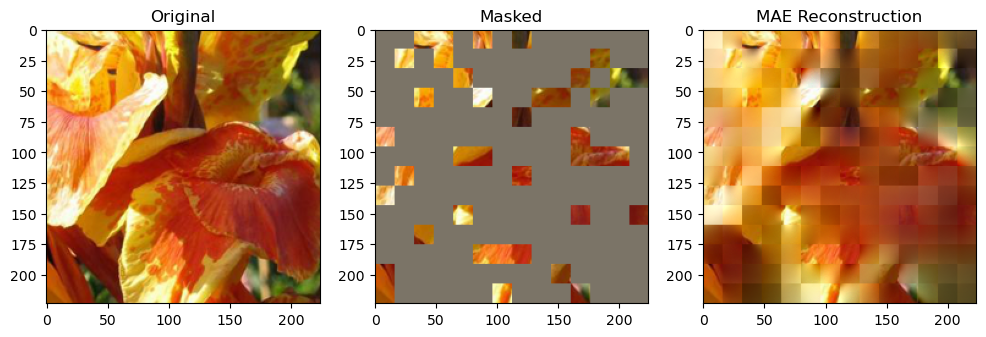

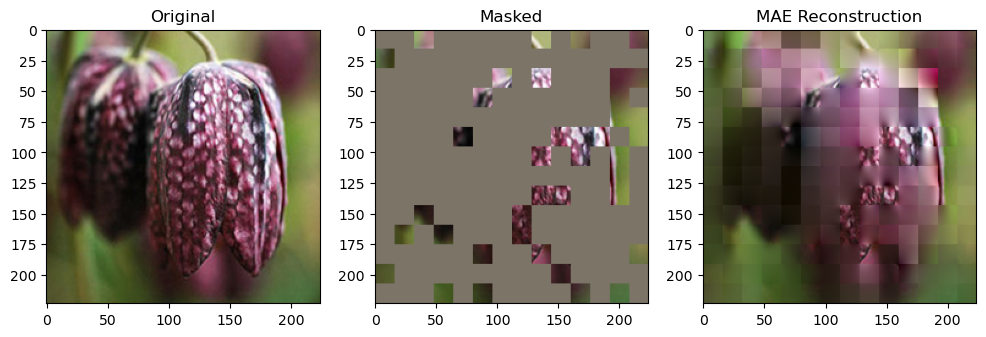

In [35]:
import torch
 
mae_train_loader = get_mae_dataloader(train_dir, batch_size=64)

checkpoint_path = "mae_vit_768_e16.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = MAEConfig() 
mae_model = MaskedAutoencoderViT(cfg).to(device)

if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    mae_model.load_state_dict(checkpoint['model_state_dict'])
    last_ep = checkpoint['epoch']
    
    results = train_mae_model(
        model=mae_model,
        train_loader=mae_train_loader,
        epochs=100,      
        lr=1.5e-4,
        checkpoint_path=checkpoint_path,
        start_epoch=last_ep 
    )
else:
    results = train_mae_model(
        model=mae_model,
        train_loader=mae_train_loader,
        epochs=100,      
        lr=1.5e-4,
        checkpoint_path=checkpoint_path,
        start_epoch=0 
    )

## Evaluate with linear probe

In [ ]:
probe_train_set = make_gpu_dataset(train_dir, simclr_test_transform, False)
probe_val_set = make_gpu_dataset(val_dir, simclr_test_transform, False)
probe_test_set = make_gpu_dataset(test_dir, simclr_test_transform, False)

probe_train_loader = DataLoader(probe_train_set, 
                          batch_size=128, 
                          shuffle=True, 
                          num_workers=4, 
                          drop_last=True)

probe_val_loader = DataLoader(probe_val_set, 
                          batch_size=128, 
                          shuffle=True, 
                          num_workers=4, 
                          drop_last=True)

probe_test_loader = DataLoader(probe_test_set, 
                          batch_size=128, 
                          shuffle=True, 
                          num_workers=4, 
                          drop_last=True)

def train_classifier(encoder: nn.Module,
                     classifier: nn.Module, 
                     train_loader: DataLoader,
                     val_loader: DataLoader,
                     epochs: int, 
                     lr: float):
    
    results = {"train_loss": [], "val_loss": []}
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)
    
    encoder.eval()
    for epoch in range(epochs):
        train_loss = 0
        train_running = 0
        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{epochs}", leave=False)
        n_batches = 0
        for sample in pbar:
            view, label = sample
            with torch.no_grad():
                features = encoder.representation(view)

            outputs = classifier(features)
            loss = criterion(outputs, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_running += float(loss.item())
            n_batches += 1
            pbar.set_postfix(loss=train_running / n_batches)
        
        train_loss = train_running / max(1, n_batches)
        
        val_loss = 0
        val_running = 0
        with torch.no_grad():
            n_batches = 0
            for sample in val_loader:
                features = encoder.representation(view)
                outputs = classifier(features)
                loss = criterion(outputs, label)
                val_running += float(loss.item())
                n_batches += 1

        val_loss = val_running / max(1, n_batches)
        results["train_loss"].append(train_loss)
        results["val_loss"].append(val_loss)
        if epoch % 10 == 0:
            print(f"epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    results['classifier'] = classifier
    return results
    

In [ ]:
linear_probe = nn.Linear(512, 102).to(device)
epochs = 250
lr = 1e-3
classifier_results = train_classifier(simCLR, linear_probe, probe_train_loader, probe_val_loader, epochs, lr)

In [ ]:
from matplotlib import pyplot as plt
plt.plot(classifier_results['train_loss'])
plt.plot(classifier_results['val_loss'])

In [ ]:
def evaluate(model, classifier, loader):
    model.eval()
    classifier.eval()
    
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            features = model.representation(images)
            outputs = classifier(features)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
train_acc = evaluate(simCLR, linear_probe, probe_train_loader)
val_acc = evaluate(simCLR, linear_probe, probe_val_loader)
test_acc = evaluate(simCLR, linear_probe, probe_test_loader)

print("Train:", train_acc)
print("Val:", val_acc)
print("Test:", test_acc)

## Evaluate with mlp

In [ ]:
class MLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

In [ ]:
mlp = MLP(512, 256, 128)
epochs = 250
lr = 1e-3
classifier_results = train_classifier(simCLR, mlp, probe_train_loader, probe_val_loader, epochs, lr)

# MAE Eval

In [40]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)

class MLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))
def train_fast_probe(classifier, train_loader, val_loader, epochs=250, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    classifier.to(device)
    
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_acc": []}

    for ep in range(epochs):
        classifier.train()
        running_loss = 0
        
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            logits = classifier(features)
            loss = criterion(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        classifier.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                logits = classifier(features)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        acc = 100 * correct / total
        history["train_loss"].append(running_loss / len(train_loader))
        history["val_acc"].append(acc)
        
        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"Epoch {ep+1}/{epochs} | Loss: {history['train_loss'][-1]:.4f} | Acc: {acc:.2f}%")

    return history

probe_test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean, std)
])

def get_probe_dataloader(data_dir, transform, batch_size=128, shuffle=True):
    dataset = ImageFolder(root=data_dir, transform=transform)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=True
    )
    return loader

# 3. Create the missing loaders
probe_train_loader = get_probe_dataloader(train_dir, probe_test_transform, shuffle=True)
probe_val_loader = get_probe_dataloader(val_dir, probe_test_transform, shuffle=False)
    

Pre-extracting features (doing the heavy lifting once)...
Pre-extracting features for 6149 images...


100%|███████████████████████████████████████████| 49/49 [00:30<00:00,  1.63it/s]


Pre-extracting features for 1020 images...


100%|█████████████████████████████████████████████| 8/8 [00:05<00:00,  1.47it/s]



Starting Linear Probe...
Epoch 1/1000 | Loss: 4.2866 | Acc: 6.08%
Epoch 10/1000 | Loss: 2.8958 | Acc: 20.78%
Epoch 20/1000 | Loss: 2.4266 | Acc: 29.61%
Epoch 30/1000 | Loss: 2.1462 | Acc: 36.37%
Epoch 40/1000 | Loss: 1.9820 | Acc: 39.90%
Epoch 50/1000 | Loss: 1.8804 | Acc: 41.57%
Epoch 60/1000 | Loss: 1.7610 | Acc: 45.29%
Epoch 70/1000 | Loss: 1.6909 | Acc: 47.25%
Epoch 80/1000 | Loss: 1.6464 | Acc: 48.33%
Epoch 90/1000 | Loss: 1.5163 | Acc: 50.10%
Epoch 100/1000 | Loss: 1.4999 | Acc: 50.29%
Epoch 110/1000 | Loss: 1.4624 | Acc: 51.67%
Epoch 120/1000 | Loss: 1.3659 | Acc: 51.86%
Epoch 130/1000 | Loss: 1.3151 | Acc: 52.55%
Epoch 140/1000 | Loss: 1.2891 | Acc: 52.94%
Epoch 150/1000 | Loss: 1.2720 | Acc: 53.53%
Epoch 160/1000 | Loss: 1.2364 | Acc: 54.71%
Epoch 170/1000 | Loss: 1.1890 | Acc: 55.88%
Epoch 180/1000 | Loss: 1.1614 | Acc: 56.18%
Epoch 190/1000 | Loss: 1.1595 | Acc: 56.57%
Epoch 200/1000 | Loss: 1.1189 | Acc: 57.25%
Epoch 210/1000 | Loss: 1.0996 | Acc: 56.76%
Epoch 220/1000 | L

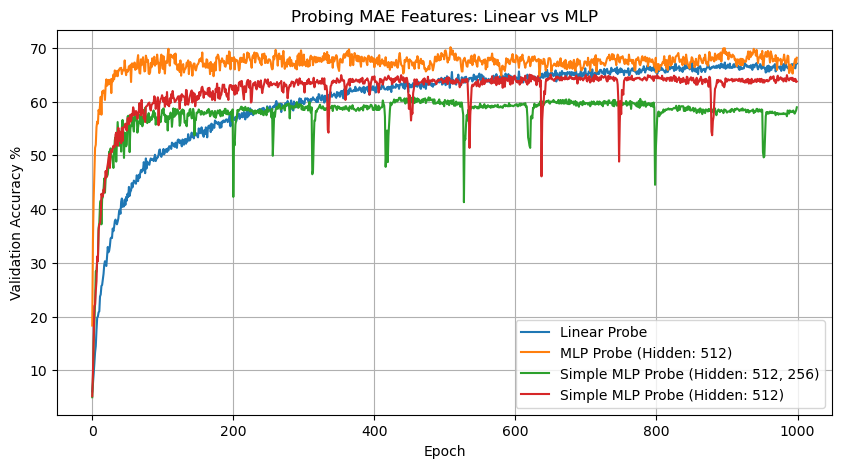

In [41]:
class MLP_3Layer(nn.Module):
    def __init__(self, dim, h1, h2, out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, h1),
            nn.GELU(),
            nn.Linear(h1, h2),
            nn.GELU(),
            nn.Linear(h2, out)
        )
    def forward(self, x): return self.net(x)

# 1. Pre-extract features
train_feat, train_labels = pre_extract_mae_features(mae_model, probe_train_loader)
val_feat, val_labels = pre_extract_mae_features(mae_model, probe_val_loader)
fast_train_loader = DataLoader(TensorDataset(train_feat, train_labels), batch_size=256, shuffle=True)
fast_val_loader = DataLoader(TensorDataset(val_feat, val_labels), batch_size=256)

-
num_classes = 102
embed_dim = 768

# Experiment 1: Linear Probe
print("\nStarting Linear Probe...")
linear_head = nn.Linear(embed_dim, num_classes)
# Note: We use the fast loader and the fast training function here
linear_history = train_fast_probe(linear_head, fast_train_loader, fast_val_loader, epochs=1000)

# MLP Probe (with BatchNorm/Dropout)
print("\nStarting MLP Probe...")
mlp_head = MLPClassifier(embed_dim, 512, num_classes)
mlp_history = train_fast_probe(mlp_head, fast_train_loader, fast_val_loader, epochs=1000)

# Simple MLP Probe (3-layer)
print("\nStarting MLP1 Probe...")
# Check your MLP definition: if it takes 4 args, use (dim, hidden1, hidden2, out)
# If your MLP only takes 3, you may need to adjust the class definition
mlp1_head = MLP_3Layer(embed_dim, 512, 256, num_classes) 
mlp1_history = train_fast_probe(mlp1_head, fast_train_loader, fast_val_loader, epochs=1000)

# Simple MLP Probe (2-layer)
print("\nStarting MLP2 Probe...")
mlp2_head = MLP(embed_dim, 512, num_classes)
mlp2_history = train_fast_probe(mlp2_head, fast_train_loader, fast_val_loader, epochs=1000)

plt.figure(figsize=(10, 5))
plt.plot(linear_history["val_acc"], label="Linear Probe")
plt.plot(mlp_history["val_acc"], label="MLP Probe (Hidden: 512)")
plt.plot(mlp1_history["val_acc"], label="Simple MLP Probe (Hidden: 512, 256)")
plt.plot(mlp2_history["val_acc"], label="Simple MLP Probe (Hidden: 512)")
plt.title("Probing MAE Features: Linear vs MLP")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy %")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
summary(mae_model)

Layer (type:depth-idx)                                       Param #
MaskedAutoencoderViT                                         253,440
├─PatchEmbed: 1-1                                            --
│    └─Conv2d: 2-1                                           590,592
├─ModuleList: 1-2                                            --
│    └─TransformerBlock: 2-2                                 --
│    │    └─LayerNorm: 3-1                                   1,536
│    │    └─MultiheadAttention: 3-2                          2,362,368
│    │    └─LayerNorm: 3-3                                   1,536
│    │    └─MLP: 3-4                                         4,722,432
│    └─TransformerBlock: 2-3                                 --
│    │    └─LayerNorm: 3-5                                   1,536
│    │    └─MultiheadAttention: 3-6                          2,362,368
│    │    └─LayerNorm: 3-7                                   1,536
│    │    └─MLP: 3-8                                    